<a href="https://colab.research.google.com/github/Egg-Lord/CCMACLRL_EXERCISES_COM232/blob/main/Exercise3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 3

Use logistic regression to predict the probability of a passenger surviving.

https://www.kaggle.com/competitions/titanic/overview

In [334]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

## Dataset File

In [335]:
dataset_url = 'https://github.com/robitussin/CCMACLRL_EXERCISES_OLD/blob/f5fdfba1aabbbafcf2fe49ca6e1c8f92f69d1458/datasets/titanic/train.csv?raw=true'
df = pd.read_csv(dataset_url)

In [336]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Data filtering

In [337]:
mean_imputer = SimpleImputer(strategy='mean')
df['Age'] = mean_imputer.fit_transform(df[['Age']])
df = df.drop('Cabin', axis=1)
df = df.drop('Fare', axis=1)
df = df.drop('Embarked', axis=1)
df = df.drop('Name', axis=1)
df = df.drop('Ticket', axis=1)

In [338]:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch']

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch']

In [339]:
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

df = pd.get_dummies(df, columns=['Pclass'], prefix='Pclass')

print(df.head())

   PassengerId  Survived  Sex   Age  SibSp  Parch  Pclass_1  Pclass_2  \
0            1         0    1  22.0      1      0     False     False   
1            2         1    0  38.0      1      0      True     False   
2            3         1    0  26.0      0      0     False     False   
3            4         1    0  35.0      1      0      True     False   
4            5         0    1  35.0      0      0     False     False   

   Pclass_3  
0      True  
1     False  
2      True  
3     False  
4      True  


In [340]:
df.head()

,PassengerId,Survived,Sex,Age,SibSp,Parch,Pclass_1,Pclass_2,Pclass_3
0,1,0,1,22.0,1,0,False,False,True
1,2,1,0,38.0,1,0,True,False,False
2,3,1,0,26.0,0,0,False,False,True
3,4,1,0,35.0,1,0,True,False,False
4,5,0,1,35.0,0,0,False,False,True


In [341]:
x = df.drop(columns=['PassengerId', 'Survived'])
y = df['Survived']

In [342]:
df.sample(10)

,PassengerId,Survived,Sex,Age,SibSp,Parch,Pclass_1,Pclass_2,Pclass_3
648,649,0,1,29.699118,0,0,False,False,True
217,218,0,1,42.000000,1,0,False,True,False
214,215,0,1,29.699118,1,0,False,False,True
461,462,0,1,34.000000,0,0,False,False,True
682,683,0,1,20.000000,0,0,False,False,True
524,525,0,1,29.699118,0,0,False,False,True
493,494,0,1,71.000000,0,0,True,False,False
509,510,1,1,26.000000,0,0,False,False,True
758,759,0,1,34.000000,0,0,False,False,True
126,127,0,1,29.699118,0,0,False,False,True


In [343]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=0)

In [344]:
model1 = LogisticRegression(max_iter=10000)
model1.fit(x_train, y_train)

LogisticRegression(max_iter=10000)

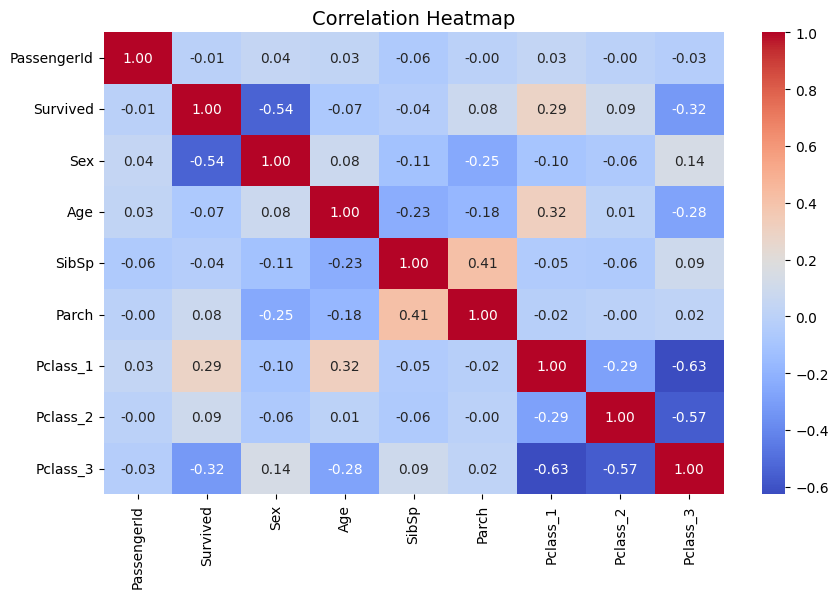

In [345]:
corr = df.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap", fontsize=14)
plt.show()

In [346]:
y_pred = log_reg.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7653631284916201

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.84      0.81       110
           1       0.71      0.65      0.68        69

    accuracy                           0.77       179
   macro avg       0.75      0.74      0.75       179
weighted avg       0.76      0.77      0.76       179


Confusion Matrix:
 [[92 18]
 [24 45]]


## Test File

In [347]:
test_url = 'https://github.com/robitussin/CCMACLRL_EXERCISES_OLD/blob/f5fdfba1aabbbafcf2fe49ca6e1c8f92f69d1458/datasets/titanic/test.csv?raw=true'
dt=pd.read_csv(test_url)

In [348]:
print(df.info())
print(dt.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Sex          891 non-null    int64  
 3   Age          891 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Pclass_1     891 non-null    bool   
 7   Pclass_2     891 non-null    bool   
 8   Pclass_3     891 non-null    bool   
dtypes: bool(3), float64(1), int64(5)
memory usage: 44.5 KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age    

In [349]:
mean_imputer = SimpleImputer(strategy='mean')
dt['Age'] = mean_imputer.fit_transform(dt[['Age']])
dt = dt.drop('PassengerId', axis=1)
dt = dt.drop('Cabin', axis=1)
dt = dt.drop('Fare', axis=1)
dt = dt.drop('Embarked', axis=1)
dt = dt.drop('Name', axis=1)
dt = dt.drop('Ticket', axis=1)


In [350]:
le = LabelEncoder()
dt['Sex'] = le.fit_transform(dt['Sex'])

dt = pd.get_dummies(dt, columns=['Pclass'], prefix='Pclass')

In [351]:
dt.sample(10)

,Sex,Age,SibSp,Parch,Pclass_1,Pclass_2,Pclass_3
260,1,36.50000,1,0,False,False,True
215,1,42.00000,0,0,True,False,False
200,0,30.27259,0,0,False,False,True
222,0,22.00000,0,0,False,True,False
163,1,30.27259,0,0,False,False,True
14,0,47.00000,1,0,True,False,False
115,1,18.00000,1,0,False,False,True
192,1,11.50000,1,1,False,False,True
352,1,18.00000,0,0,False,True,False
45,1,25.00000,0,0,False,False,True


In [352]:
df.sample(10)

,PassengerId,Survived,Sex,Age,SibSp,Parch,Pclass_1,Pclass_2,Pclass_3
188,189,0,1,40.0,1,1,False,False,True
794,795,0,1,25.0,0,0,False,False,True
206,207,0,1,32.0,1,0,False,False,True
314,315,0,1,43.0,1,1,False,True,False
246,247,0,0,25.0,0,0,False,False,True
535,536,1,0,7.0,0,2,False,True,False
88,89,1,0,23.0,3,2,True,False,False
437,438,1,0,24.0,2,3,False,True,False
822,823,0,1,38.0,0,0,True,False,False
315,316,1,0,26.0,0,0,False,False,True


In [353]:
print(df.info())
print(dt.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Sex          891 non-null    int64  
 3   Age          891 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Pclass_1     891 non-null    bool   
 7   Pclass_2     891 non-null    bool   
 8   Pclass_3     891 non-null    bool   
dtypes: bool(3), float64(1), int64(5)
memory usage: 44.5 KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Sex       418 non-null    int64  
 1   Age       418 non-null    float64
 2   SibSp     418 non-null    int64  
 3   Parch     418 non-null    int64  
 4   Pclass_1  418 non-null    

## Sample Submission File

In [354]:
sample_submission_url ='https://github.com/robitussin/CCMACLRL_EXERCISES_OLD/blob/f5fdfba1aabbbafcf2fe49ca6e1c8f92f69d1458/datasets/titanic/gender_submission.csv?raw=true'

sf=pd.read_csv(sample_submission_url)

In [355]:
sf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB


## Generate Results

In [356]:
dt.head()

,Sex,Age,SibSp,Parch,Pclass_1,Pclass_2,Pclass_3
0,1,34.5,0,0,False,False,True
1,0,47.0,1,0,False,False,True
2,1,62.0,0,0,False,True,False
3,1,27.0,0,0,False,False,True
4,0,22.0,1,1,False,False,True


In [357]:
id = sf.pop('PassengerId')
y_pred = model1.predict(dt)

# Create a submission DataFrame
submission_df = pd.DataFrame({
    'PassengerId': id,
    'Survived': y_pred
})

# Save the submission DataFrame to a CSV file
submission_df.to_csv('submission_file.csv', index=False)
print("Submission file created: submission_file.csv")

Submission file created: submission_file.csv
